# Описание данных

Данные - специально подготовленная выборка из полного набора, описанного здесь: https://mengtingwan.github.io/data/goodreads#datasets с дополнениями из https://www.kaggle.com/datasets/austinreese/goodreads-books:
- books: перечень книг (~44 тыс.) из списка https://www.goodreads.com/list/show/1.Best_Books_Ever (совпадение по book id),
- interactions: взаимодействие пользователей с книгами

Основной массив данных был собран в конце 2017.

# Инициализация

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [192]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

Создаём логгер, который удобен для использования в ноутбуке.

# Load Data

Загружаем данные как они есть, начинаем на них смотреть: какие в них есть сущности, атрибуты, распределения.

In [3]:
books = pd.read_parquet("./data/goodsread/books.parquet")

In [194]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43312 entries, 3 to 2360448
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   book_id               43312 non-null  int64  
 1   author                43312 non-null  object 
 2   title                 43312 non-null  object 
 3   description           43312 non-null  object 
 4   genre_and_votes       43312 non-null  object 
 5   num_pages             37001 non-null  Int64  
 6   average_rating        43312 non-null  float64
 7   ratings_count         43312 non-null  Int64  
 8   text_reviews_count    43312 non-null  int64  
 9   publisher             43312 non-null  object 
 10  publication_year      35891 non-null  Int64  
 11  country_code          43312 non-null  object 
 12  language_code         43312 non-null  object 
 13  format                43312 non-null  object 
 14  is_ebook              43312 non-null  bool   
 15  isbn                  

Пример данных по книгам

In [195]:
books.head()

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
3,6066819,Jennifer Weiner,Best Friends Forever,Addie Downs and Valerie Adler were eight when ...,"{'Womens Fiction-Chick Lit': 739, 'Fiction': 442}",368,3.49,51184,3282,Atria Books,2009,US,eng,Hardcover,False,0743294297,9780743294294,"{'Academic': None, 'Academic-Academia': None, ...","Womens Fiction-Chick Lit 739, Fiction 442"
6,378460,Michael Halberstam,The Wanting of Levine,,"{'Politics': 1, 'Humor': 1}",<NA>,4.38,12,4,Berkley Publishing Group,1979,US,,Paperback,False,0425040887,9780425040881,"{'Academic': None, 'Academic-Academia': None, ...","Politics 1user, Humor 1user"
15,89375,"Don Piper, Cecil Murphey",90 Minutes in Heaven: A True Story of Death an...,As he is driving home from a minister's confer...,"{'Christian': 395, 'Nonfiction': 392, 'Religio...",<NA>,3.91,68157,2885,,<NA>,US,,,False,0800759494,9780800759490,"{'Academic': None, 'Academic-Academia': None, ...","Christian 395, Nonfiction 392, Religion 142, S..."
16,89376,Randy Alcorn,Heaven,What is Heaven really going to be like? What w...,"{'Christian': 225, 'Religion-Theology': 154, '...",533,4.26,7345,566,,<NA>,US,eng,,False,0842379428,9780842379427,"{'Academic': None, 'Academic-Academia': None, ...","Christian 225, Religion-Theology 154, Nonficti..."
17,89377,Jennifer L. Holm,Penny from Heaven,It's 1953 and 11-year-old Penny dreams of a su...,"{'Historical-Historical Fiction': 284, 'Childr...",288,3.98,6949,615,Random House Books for Young Readers,2006,US,,Hardcover,False,037583687X,9780375836879,"{'Academic': None, 'Academic-Academia': None, ...","Historical-Historical Fiction 284, Childrens-M..."


In [196]:
books[["book_id", "author", "title", "num_pages", "average_rating"]].sample(5, random_state=52).sort_values("book_id").set_index("book_id")

,author,title,num_pages,average_rating
book_id,,,,
69882,"Heinrich Böll, Patrick Bowles",Billiards at Half-Past Nine,288,3.93
267533,Robert Cormier,8 Plus 1,173,3.67
820966,"Martin Luther, J.I. Packer, O.R. Johnston",The Bondage of the Will,322,4.17
4532622,Karen Hancock,The Enclave,492,3.82
20444381,Diana Gabaldon,Os tambores de outono - 1ª Parte (Outlander #4),1048,3.99


In [4]:
interactions = pd.read_parquet("./data/goodsread/interactions.parquet")

Можно оценить объём данных о взаимодействиях

In [5]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12890434 entries, 0 to 12914458
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      object
 1   book_id      int64 
 2   started_at   object
 3   read_at      object
 4   is_read      bool  
 5   rating       int64 
 6   is_reviewed  bool  
dtypes: bool(2), int64(2), object(3)
memory usage: 614.7+ MB


Пример данных по взаимодействиям

In [199]:
interactions.head()

,user_id,book_id,started_at,read_at,is_read,rating,is_reviewed
0,8842281e1d1347389f2ab93d60773d4d,22034,2015-07-12,2015-07-17,True,5,False
1,8842281e1d1347389f2ab93d60773d4d,22318578,2015-06-07,2015-08-09,True,5,True
2,8842281e1d1347389f2ab93d60773d4d,22551730,2015-06-24,2015-07-11,True,4,True
3,8842281e1d1347389f2ab93d60773d4d,22816087,2015-09-27,2015-11-04,True,5,True
4,8842281e1d1347389f2ab93d60773d4d,20527133,2015-05-05,2015-09-06,True,0,False


In [200]:
interactions[["user_id", "book_id", "started_at", "read_at", "is_read", "rating"]].sample(5, random_state=52).sort_values("user_id").set_index(["user_id", "book_id"])

,,started_at,read_at,is_read,rating
user_id,book_id,,,,
0447747f44c0d8d1a08cf329fe253f29,10054335,2016-04-08,2016-04-20,True,3
14432756ffba6357686f09e4ccc332bb,26252859,2016-05-27,2016-05-30,True,5
46d6c8cf548d1c86abb671f42ba71b5e,960,2014-08-06,2016-10-29,True,5
71c2b3714945af1f700f49953904c510,18492859,2014-10-09,2014-10-12,True,5
7802bafdeac8abff23a72b9dd60b1dd1,18710190,2015-03-01,2015-05-05,True,4


# EDA - мой вариант EDA

In [201]:
# для тестов понизим размерность
#books = books.sample(10000)
#interactions = interactions.sample(100000)

In [202]:
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_columns')

#pd.set_option('display.max_colwidth', None)
pd.reset_option('display.max_colwidth')

In [203]:
books.isna().sum()

book_id                    0
author                     0
title                      0
description                0
genre_and_votes            0
num_pages               6311
average_rating             0
ratings_count              0
text_reviews_count         0
publisher                  0
publication_year        7421
country_code               0
language_code              0
format                     0
is_ebook                   0
isbn                       0
isbn13                     0
genre_and_votes_dict     921
genre_and_votes_str      921
dtype: int64

In [204]:
interactions.isna().sum()

user_id        0
book_id        0
started_at     0
read_at        0
is_read        0
rating         0
is_reviewed    0
dtype: int64

In [205]:
#сколько пользователей
interactions['user_id'].unique().shape

(542657,)

In [206]:
import seaborn as sns

In [207]:
# Сколько пользователей читали книги
# распределение популярности (долю пользователей, приходящуюся на одну книгу)

books_count = interactions[['book_id']].groupby(by='book_id').agg(count=('book_id', 'count')).sort_values('count', ascending=False).reset_index()
books_count


,book_id,count
0,22557272,45201
1,11870085,44238
2,11735983,32673
3,13335037,30746
4,9460487,30392
...,...,...
41907,1522679,1
41908,1523931,1
41909,173590,1
41910,173907,1


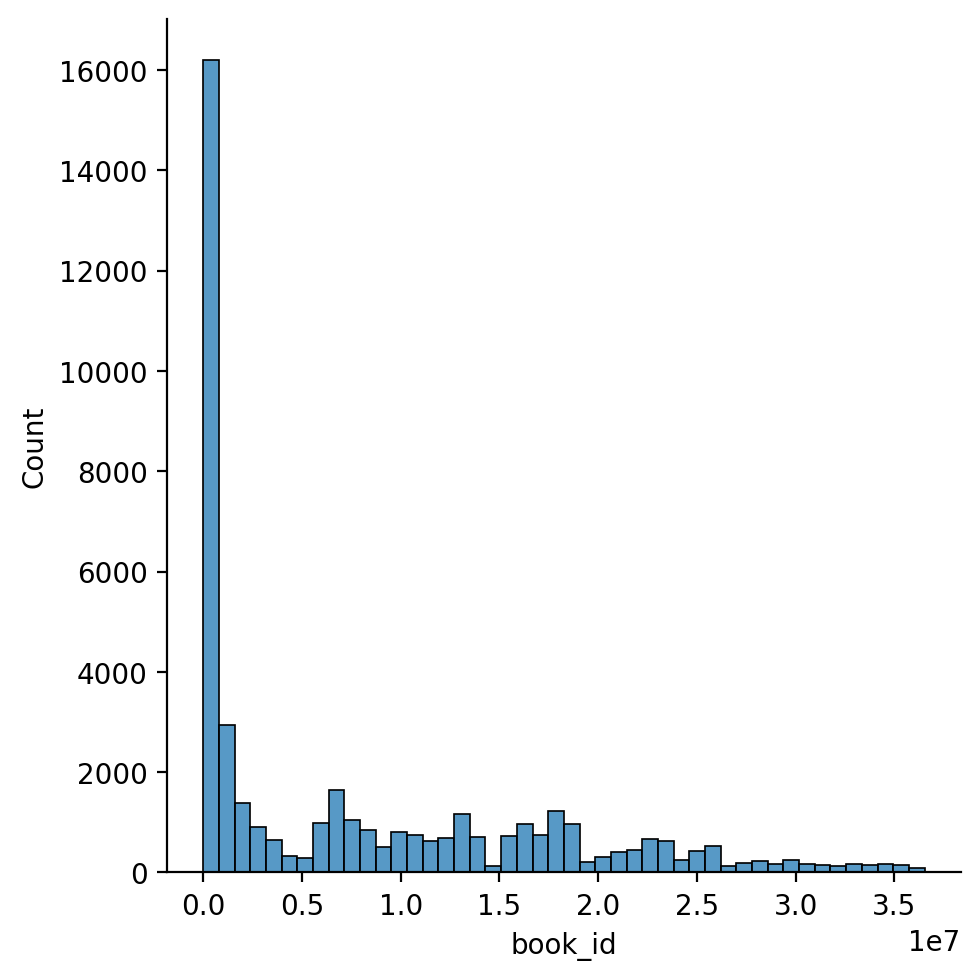

In [208]:
sns.displot(books, x='book_id')

<Axes: >

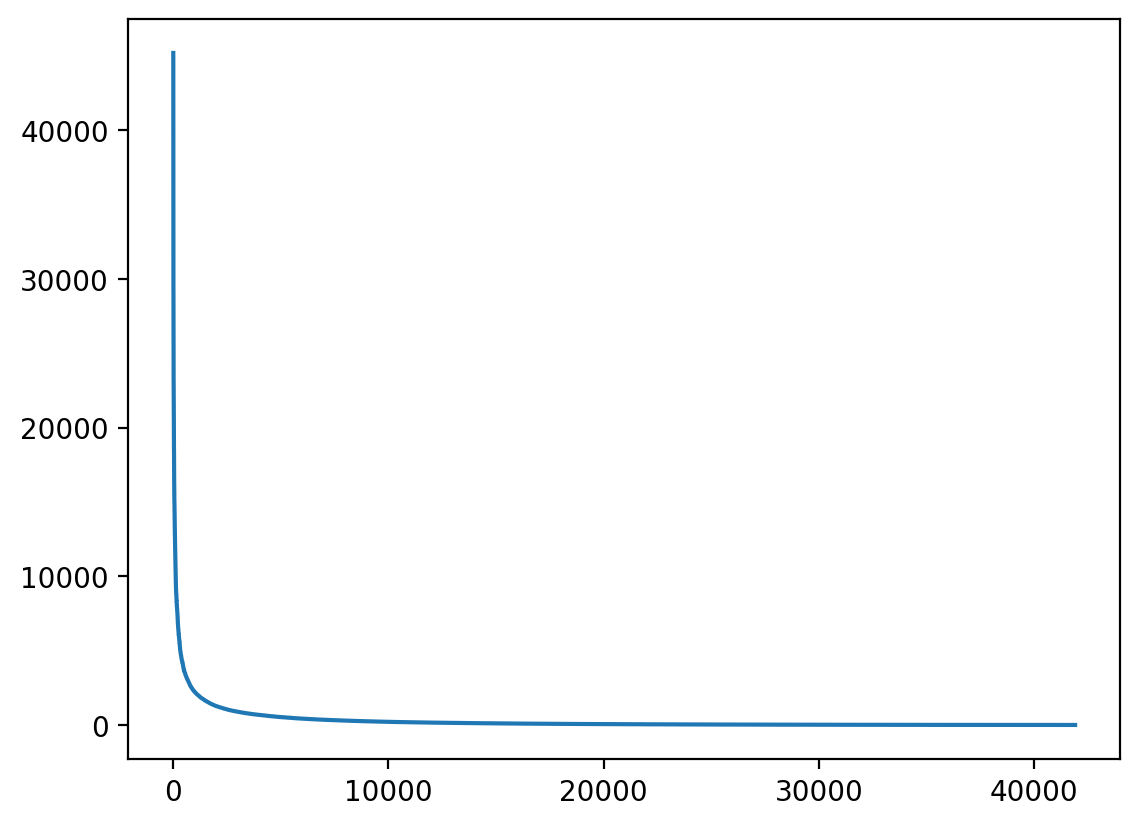

In [209]:
books_count['count'].plot()

In [210]:
bb = books.merge(books_count, on='book_id')
bb.sort_values(by='count', ascending=False).head(10)

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str,count
35238,22557272,Paula Hawkins,The Girl on the Train,Every day the same\nRachel takes the same comm...,"{'Fiction': 9793, 'Mystery': 9190, 'Thriller':...",323,3.88,1076144,78438,Riverhead Books,2015,US,eng,Hardcover,False,1594633665,9781594633669,"{'Academic': None, 'Academic-Academia': None, ...","Fiction 9793, Mystery 9190, Thriller 6974, Mys...",45201
35356,11870085,John Green,The Fault in Our Stars,"There is an alternate cover edition .\n""I fel...","{'Young Adult': 20449, 'Fiction': 10338, 'Roma...",313,4.26,2429317,129572,Dutton Books,2012,US,eng,Hardcover,False,0525478817,9780525478812,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 20449, Fiction 10338, Romance 1019...",44238
39323,11735983,Veronica Roth,"Insurgent (Divergent, #2)",One choice can transform you--or it can destro...,"{'Young Adult': 13994, 'Science Fiction-Dystop...",525,4.07,849014,49228,HarperCollins Children's Books,2012,US,eng,Hardcover,False,0007442912,9780007442911,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 13994, Science Fiction-Dystopia 10...",32673
40673,13335037,Veronica Roth,"Divergent (Divergent, #1)",Paperback features over fifty pages of bonus m...,"{'Young Adult': 20260, 'Science Fiction-Dystop...",487,4.23,1962813,68482,Katherine Tegen Books,2012,US,eng,Paperback,False,0062024035,9780062024039,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 20260, Science Fiction-Dystopia 13...",30746
29658,9460487,Ransom Riggs,Miss Peregrine’s Home for Peculiar Children (M...,A mysterious island. An abandoned orphanage. A...,"{'Fantasy': 12454, 'Young Adult': 9293, 'Ficti...",352,3.89,641884,46665,Quirk,<NA>,US,en-US,,False,1594744769,9781594744761,"{'Academic': None, 'Academic-Academia': None, ...","Fantasy 12454, Young Adult 9293, Fiction 4646",30392
2444,7260188,Suzanne Collins,"Mockingjay (The Hunger Games, #3)",My name is Katniss Everdeen.\nWhy am I not dea...,"{'Young Adult': 24130, 'Science Fiction-Dystop...",392,4.03,1743362,86946,Scholastic Press,2010,US,eng,Hardcover,False,0439023513,9780439023511,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 24130, Science Fiction-Dystopia 12...",30188
9299,2767052,Suzanne Collins,"The Hunger Games (The Hunger Games, #1)",Winning will make you famous.\nLosing means ce...,"{'Young Adult': 30042, 'Fiction': 16754, 'Scie...",374,4.34,4899965,142645,Scholastic Press,2008,US,eng,Hardcover,False,0439023483,9780439023481,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 30042, Fiction 16754, Science Fict...",29811
37649,29056083,"John Tiffany, Jack Thorne, J.K. Rowling",Harry Potter and the Cursed Child - Parts One ...,The Eighth Story. Nineteen Years Later.\nIt wa...,"{'Fantasy': 14466, 'Fiction': 4232, 'Young Adu...",343,3.74,288018,36121,"Little, Brown",2016,US,eng,Hardcover,False,0751565350,9780751565355,"{'Academic': None, 'Academic-Academia': None, ...","Fantasy 14466, Fiction 4232, Young Adult 3692,...",29264
26835,6148028,Suzanne Collins,"Catching Fire (The Hunger Games, #2)",Sparks are igniting.\nFlames are spreading.\nA...,"{'Young Adult': 25542, 'Science Fiction-Dystop...",391,4.30,1854746,80495,Scholastic Press,2009,US,eng,Hardcover,False,0439023491,9780439023498,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 25542, Science Fiction-Dystopia 13...",29047
37232,15745753,Rainbow Rowell,Eleanor & Park,Two misfits.\nOne extraordinary love.\nEleanor...,"{'Young Adult': 11593, 'Romance': 6881, 'Conte...",328,4.11,537595,43120,St. Martin's Press,2013,US,eng,Hardcover,False,1250012570,9781250012579,"{'Academic': None, 'Academic-Academia': None, ...","Young Adult 11593, Romance 6881, Contemporary ...",27248


In [211]:
# сколько пользователи в среднем прочитали книг
books_count_avg = books_count['count'].mean()
books_count_avg

307.5595056308456

In [212]:
# сколько книг прочтено пользователем
users_count = interactions[['user_id']].groupby('user_id').agg(count=('user_id', 'count')).sort_values('count', ascending=False).reset_index()
users_count


,user_id,count
0,16b09d050bdd8d9c23920b811f51472d,3204
1,0cbea2d29549eb2960fe81a58fc7354e,1385
2,4117fd790b397a6d6ce61f4dbff678cf,1332
3,c14a1cde055557f4544fcb6be5ea5710,1193
4,aca760854b57ce2ec981df32e46dc96c,1182
...,...,...
542652,fff49838fc403ae3152a2407ca3841ed,1
542653,fff4998267dee276e004d427aa975d4f,1
542654,747236681f4cf4c89257d167b63a4bce,1
542655,5d94987e17fcac2f96e599c7e76814ad,1


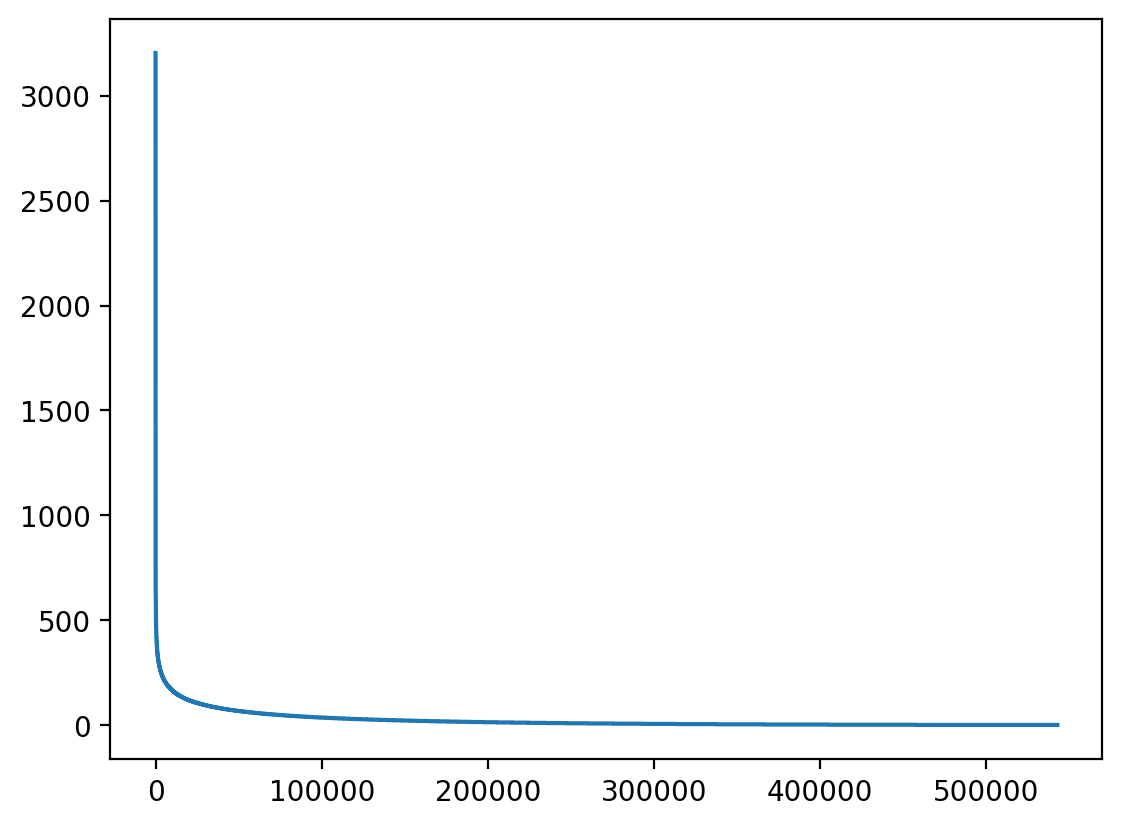

In [213]:
plt.plot(users_count['count'])

In [214]:
# сколько книг в среднем было прочтено пользователем

books_users_avg = users_count['count'].mean()
books_users_avg

23.7542941489744

In [215]:
# доля прочитанных книг, у которых нет рейтинга - rating = 0
# распределение рейтинга,
interactions_ratings = interactions[['user_id', 'rating']].groupby('rating').agg(count=('user_id','count')).reset_index()
interactions_ratings

,rating,count
0,0,1051672
1,1,183770
2,2,671089
3,3,2564629
4,4,4559434
5,5,3859840


<Axes: xlabel='rating', ylabel='count'>

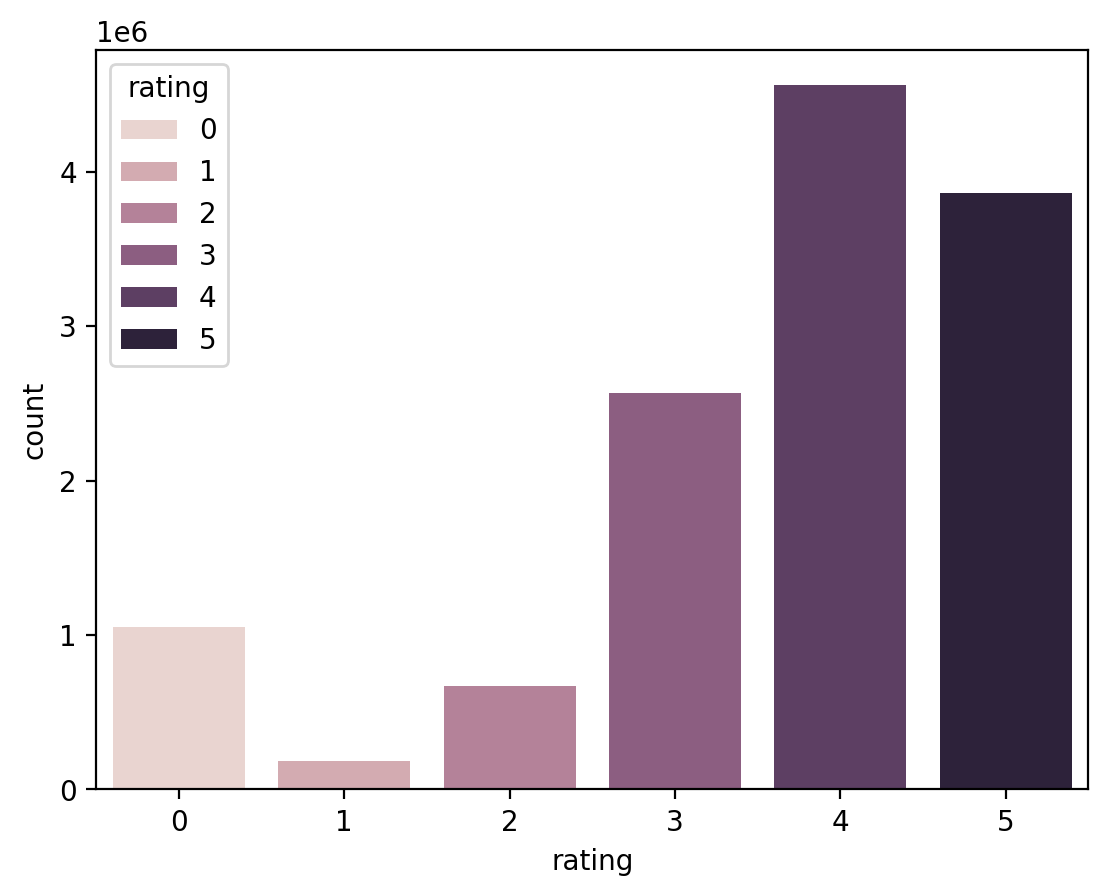

In [216]:
sns.barplot(interactions_ratings, x='rating', y='count', hue='rating')

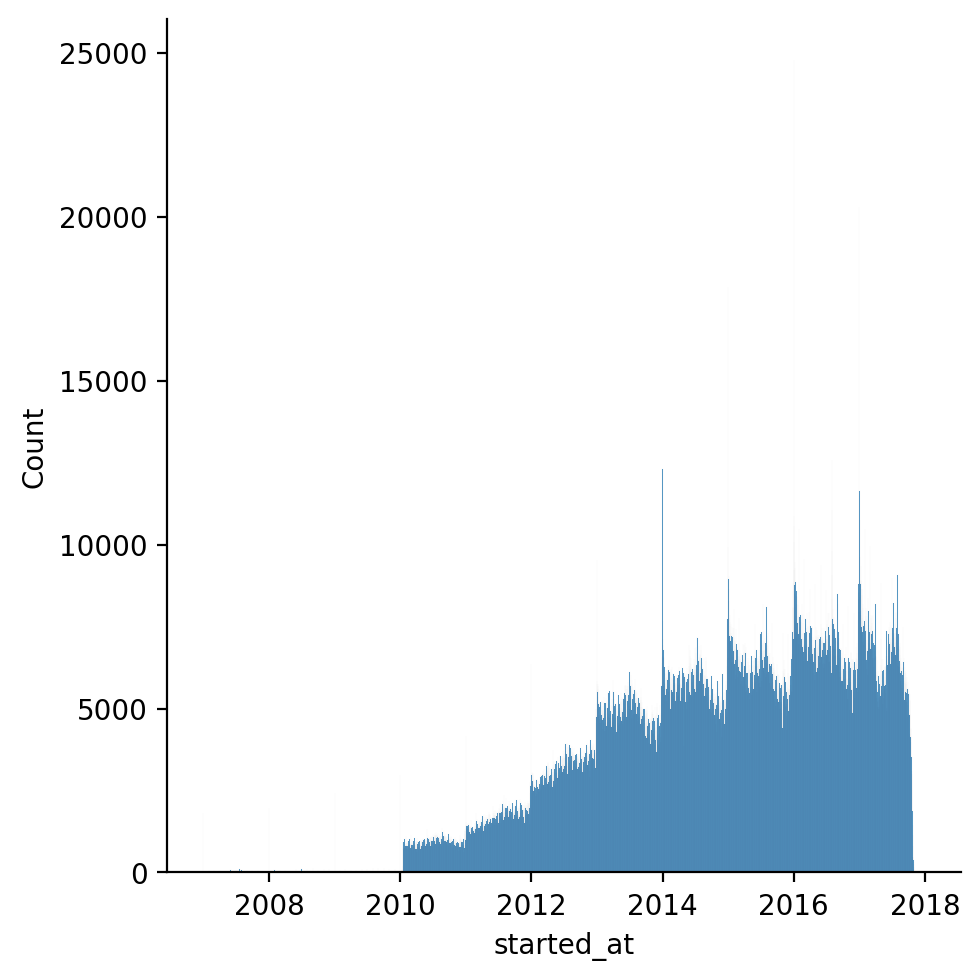

In [217]:
#распределение количества взаимодействий во времени
interactions.head()

sns.displot(interactions, x='started_at')


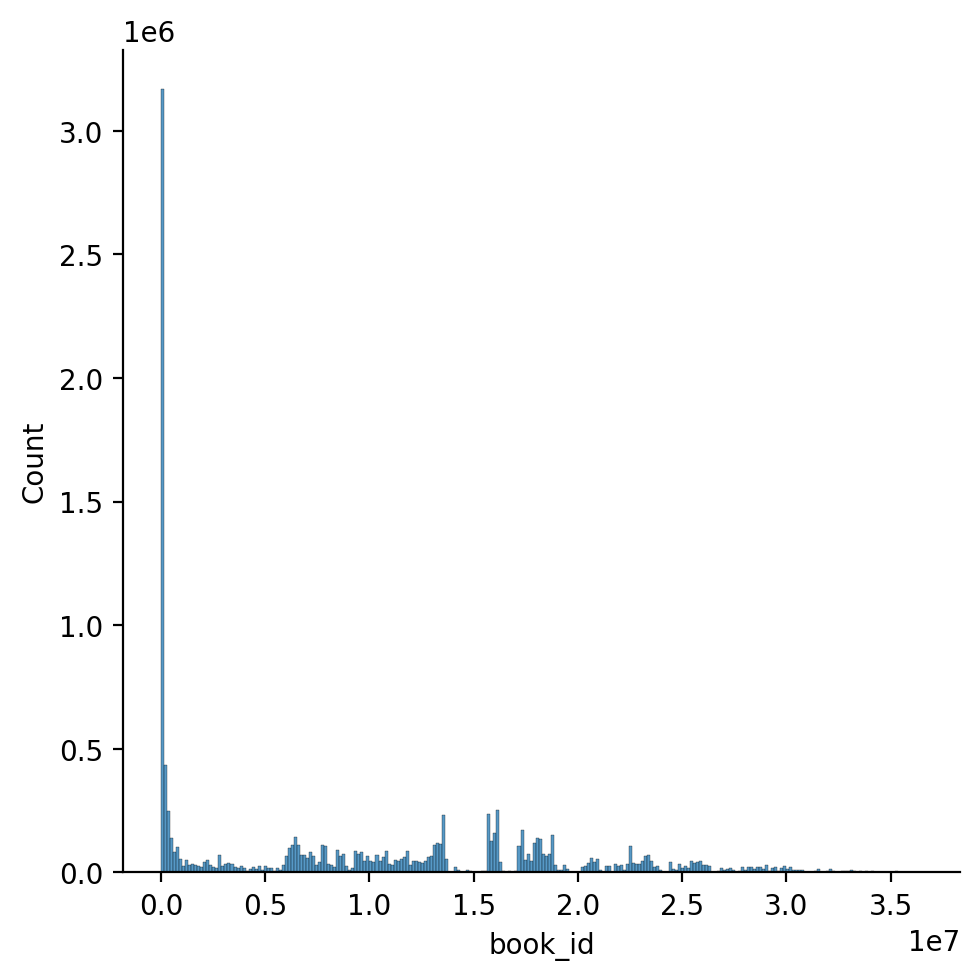

In [218]:
sns.displot(interactions, x='book_id')

In [219]:
starts = interactions.groupby(by='started_at').agg(count=('user_id', 'count')).reset_index()
starts

,started_at,count
0,2007-01-01,1804
1,2007-01-02,9
2,2007-01-03,7
3,2007-01-04,6
4,2007-01-05,12
...,...,...
3983,2017-12-26,2
3984,2017-12-27,2
3985,2017-12-28,4
3986,2017-12-30,2


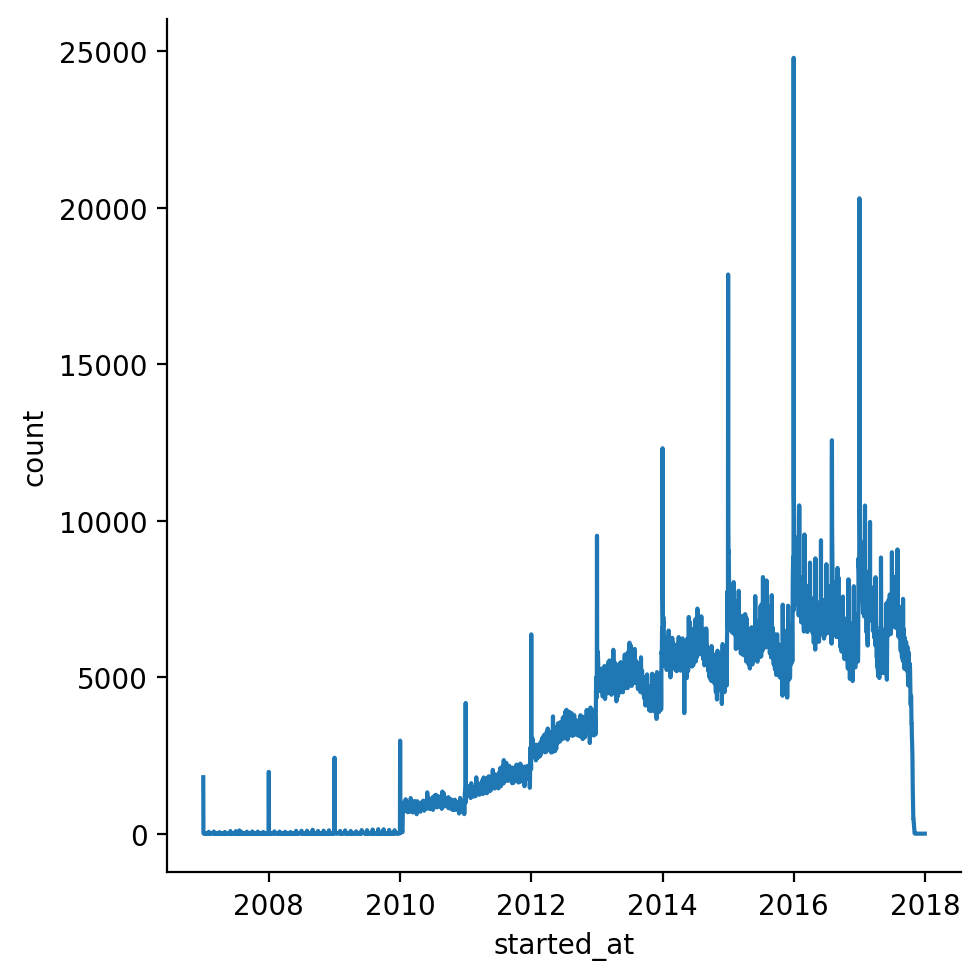

In [220]:
sns.relplot(starts, x='started_at', y='count', kind='line')

In [221]:
books.query('publication_year > 2030')

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
149972,16111549,Adrienne Thompson,See Me,Olivia Moy is ready to tell her story. Can you...,"{'Cultural-African American': 1, 'Health-Menta...",216,4.32,61,11,Pink Cashmere Publishing Co.,20121,US,en-US,ebook,True,,,"{'Academic': None, 'Academic-Academia': None, ...","Cultural-African American 1user, Health-Mental..."
579456,18626461,Collette Sinclaire,Messages From Heaven,Collette Sinclaire has spent the last 7 years ...,None,198,4.27,59,5,Risch Media Group,20136,US,eng,ebook,True,,,None,None
909987,23200119,Byron Goines,The 2014 Midterm Elections,Audible Audiobook http://www.audible.com/pd/?a...,None,<NA>,5.00,1,1,Byron Goines,2104,US,eng,Audiobook,False,,,None,None
1026902,13487352,Agustí Vehí,Torn de nit,La peticio d'un informe a carrec de l'excel*le...,None,159,3.50,8,4,Alreves,20112,US,cat,Paperback,False,,9788415098409,None,None
1680779,32825168,Janet E. Morris,"Wind from the Abyss (Silistra, #3)",She was descended from the masters of the univ...,"{'Fantasy': 14, 'Science Fiction': 6, 'Science...",309,4.12,17,6,Perseid Press,2106,US,eng,Kindle Edition,True,,,"{'Academic': None, 'Academic-Academia': None, ...","Fantasy 14, Science Fiction 6, Science Fiction..."
1846662,6989790,Al Gore,Our Choice: A Plan to Solve the Climate Crisis,A co-recipient of the Nobel Peace Prize in 200...,"{'Nonfiction': 49, 'Science': 29, 'Environment...",416,3.99,555,89,Random House Canada,2035,US,eng,Paperback,False,0307358062,9780307358066,"{'Academic': None, 'Academic-Academia': None, ...","Nonfiction 49, Science 29, Environment 22, Pol..."
2335611,17984095,Mila Roth,Operation Maulwurf,Wer verbirgt sich hinter der Maske?\nNur knapp...,{'Mystery-Crime': 1},172,4.43,13,5,CreateSpace Independent Publishing Platform,3013,US,ger,Paperback,False,1484938682,9781484938683,"{'Academic': None, 'Academic-Academia': None, ...",Mystery-Crime 1user


In [222]:
books.query('publication_year < 1900')

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
9876,6657114,"Nizami Ganjavi, منوچهر آدمیت, صادق صندوقی, عبا...",خسرو و شیرین از پنج گنج حکیم نظامی,khsrw w shyryn z pnj gnj Hkhym nZmy mqblh b m`...,"{'Poetry': 29, 'Literature': 7}",208,4.13,19,2,ntshrt atlyh hnr,1371,US,per,Hardcover,False,,,"{'Academic': None, 'Academic-Academia': None, ...","Poetry 29, Literature 7"
538446,4526691,"راضیه دهقان سلماسی, فرشید مثقالی",من و خارپشت و عروسکم,,{'Childrens': 2},40,4.52,62,21,khnwn prwrsh fkhry khwdkhn w nwjwnn,1357,US,per,paperback,False,,,"{'Academic': None, 'Academic-Academia': None, ...",Childrens 2
628487,1642216,Nellie Bly,Ten Days in a Mad-House,,"{'Nonfiction': 588, 'History': 254, 'Classics'...",92,3.82,2565,356,Norman L. Munro,1887,US,eng,,False,,,"{'Academic': None, 'Academic-Academia': None, ...","Nonfiction 588, History 254, Classics 132, Psy..."
837067,2858266,"Robin Walker, Fari Supiya",When We Ruled: The Ancient and Medieval Histor...,When We Ruledis by far the best general work o...,"{'History': 28, 'Nonfiction': 18, 'Cultural-Af...",713,4.38,99,7,Every Generation Media,206,US,en-GB,Hardcover,False,095510680X,9780955106804,"{'Academic': None, 'Academic-Academia': None, ...","History 28, Nonfiction 18, Cultural-Africa 14,..."
1222584,17229241,Friedrich Nietzsche,On Truth and Lies in a Nonmoral Sense,,"{'Philosophy': 134, 'Nonfiction': 37, 'Classic...",8,4.25,363,15,,1873,US,,,False,,,"{'Academic': None, 'Academic-Academia': None, ...","Philosophy 134, Nonfiction 37, Classics 9, Eur..."
1598791,26204674,"Liz Pichon, آتوسا صالحی","دنیای معرکه ی تام گیتس(Tom Gates, #1)",Tom Gates is the master of excuses for late ho...,"{'Childrens-Middle Grade': 26, 'Childrens': 25...",256,4.20,2,1,fq,1394,US,per,,False,,,"{'Academic': None, 'Academic-Academia': None, ...","Childrens-Middle Grade 26, Childrens 25, Humor..."
1637948,6557009,Richard C. Woolfson,بماذا يفكر طفلي؟,mt~ ybd' l'Tfl lrD` blt`rf l~ mn`ksthm lkhS@? ...,None,144,4.08,46,4,'kdymy ntrnshwnl,23,US,ara,,False,,,None,None
1641775,11200941,Fyodor Dostoyevsky,Uncle's Dream,,"{'Fiction': 31, 'Cultural-Russia': 30, 'Classi...",135,3.67,603,41,Vizetelly and Co.,1888,US,eng,Kindle Edition,True,,,"{'Academic': None, 'Academic-Academia': None, ...","Fiction 31, Cultural-Russia 30, Classics 27, L..."
1694735,646462,Anonymous,The Qur'an / القرآن الكريم,The Quran (English pronunciation: /kor'a:n/; A...,"{'Religion': 1301, 'Religion-Islam': 473, 'Non...",604,4.34,32762,1383,,650,US,ara,Hardcover,False,,,"{'Academic': None, 'Academic-Academia': None, ...","Religion 1301, Religion-Islam 473, Nonfiction ..."
1711349,6097536,"عمرو خالد, عمرو خالد",إصلاح القلوب,,{'Religion': 5},318,4.17,655,68,ldr l`rby@ ll`lwm,1424,US,ara,Paperback,False,,,"{'Academic': None, 'Academic-Academia': None, ...",Religion 5


In [225]:
years = books.query('publication_year < 2030')['publication_year'].value_counts().reset_index()
years

,publication_year,count
0,2012,2827
1,2013,2820
2,2011,2410
3,2014,2226
4,2006,1958
...,...,...
109,1394,1
110,23,1
111,1888,1
112,13,1


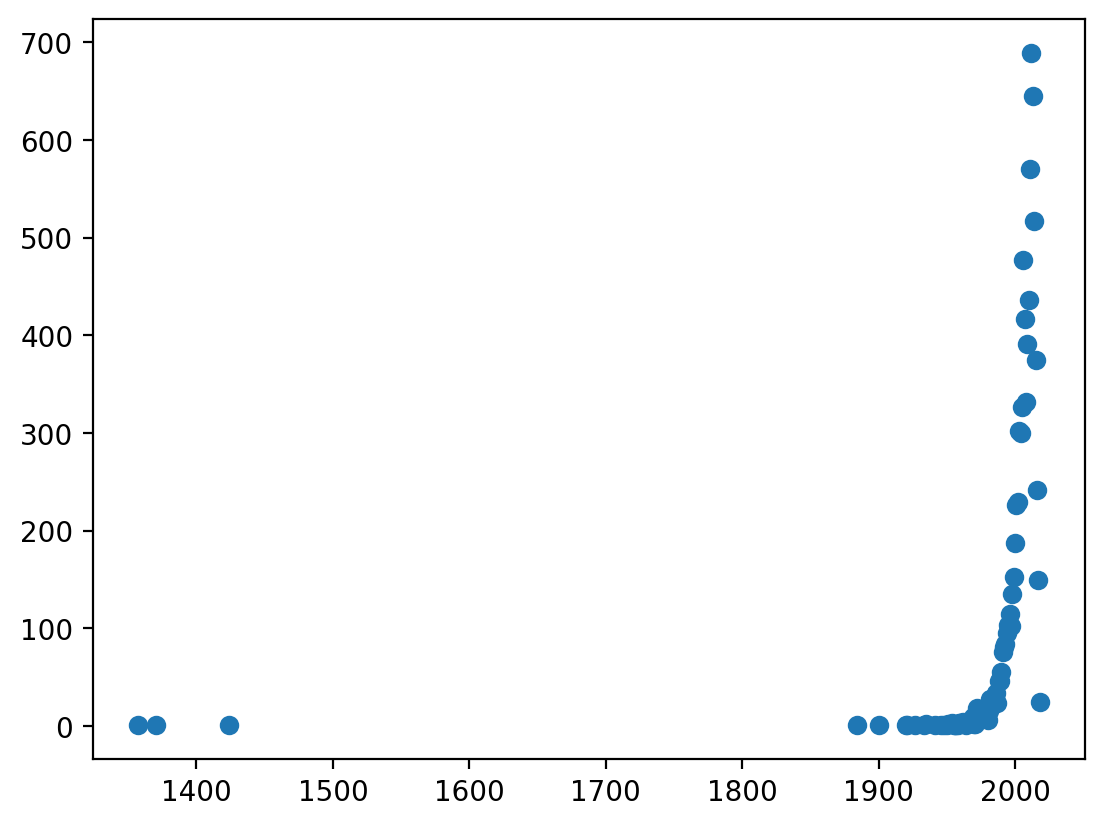

In [ ]:
plt.scatter(years['publication_year'], years['count'])

<BarContainer object of 80 artists>

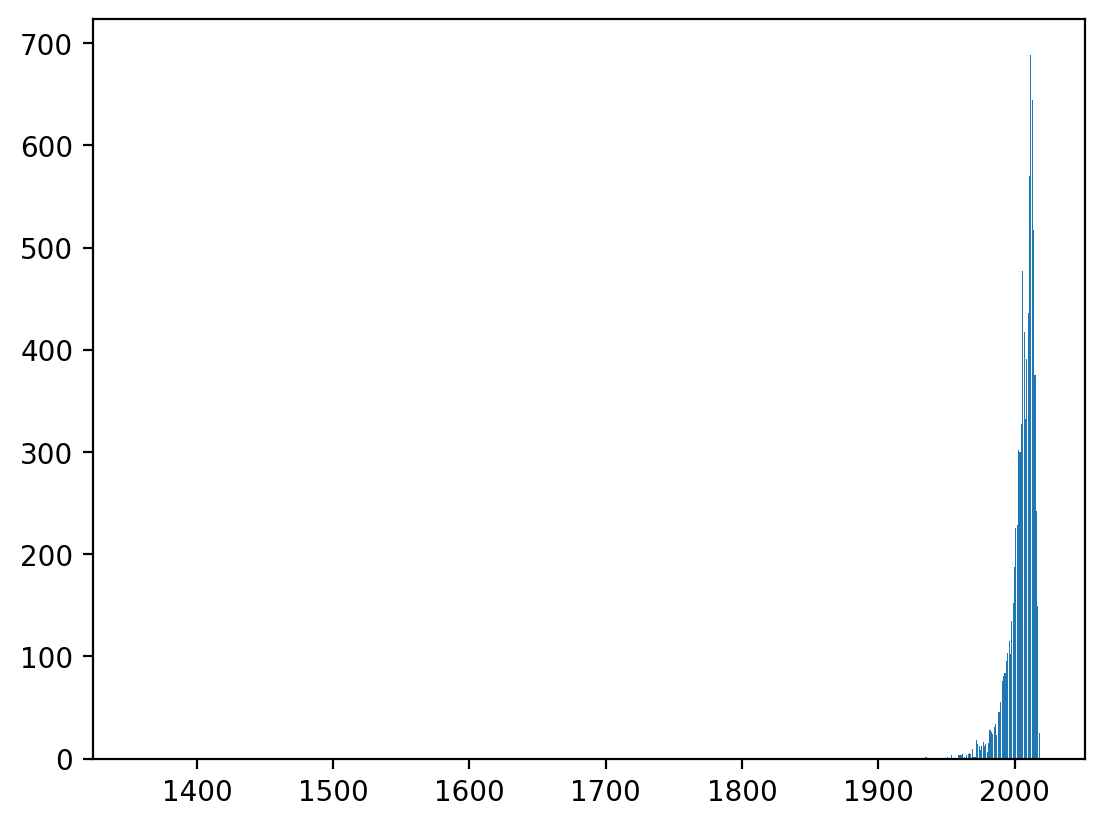

In [ ]:
plt.bar(x=years['publication_year'], height=years['count'])

# EDA

Посмотрим на данные о книгах, какие поля есть.

In [ ]:
books.sample(3).T

,1717455,1873681,172667
book_id,18485973,10109832,9955669
author,Rachel Van Dyken,Mercedes Keyes,Rick Yancey
title,"The Wager (The Bet, #2)",The Fancy (The Fancy Series #1),"The Isle of Blood (The Monstrumologist, #3)"
description,"THE WAGER\nLose a bet, lose your heart...\nWha...","The slave trader, ""fancy"" dealer was saving th...","When Dr. Warthrop goes hunting the ""Holy Grail..."
genre_and_votes,"{'Romance': 181, 'New Adult': 82, 'Contemporar...","{'Romance-Historical Romance': 14, 'Romance-In...","{'Horror': 318, 'Young Adult': 211, 'Fantasy':..."
num_pages,256,260,538
average_rating,4.15,4.19,4.25
ratings_count,4390,320,3399
text_reviews_count,272,28,397
publisher,Forever,Lulu,Simon Schuster Books for Young Readers


Посмотрим на данные о взаимодействиях пользователей с книгами.

In [ ]:
books["book_id"].nunique()

43312

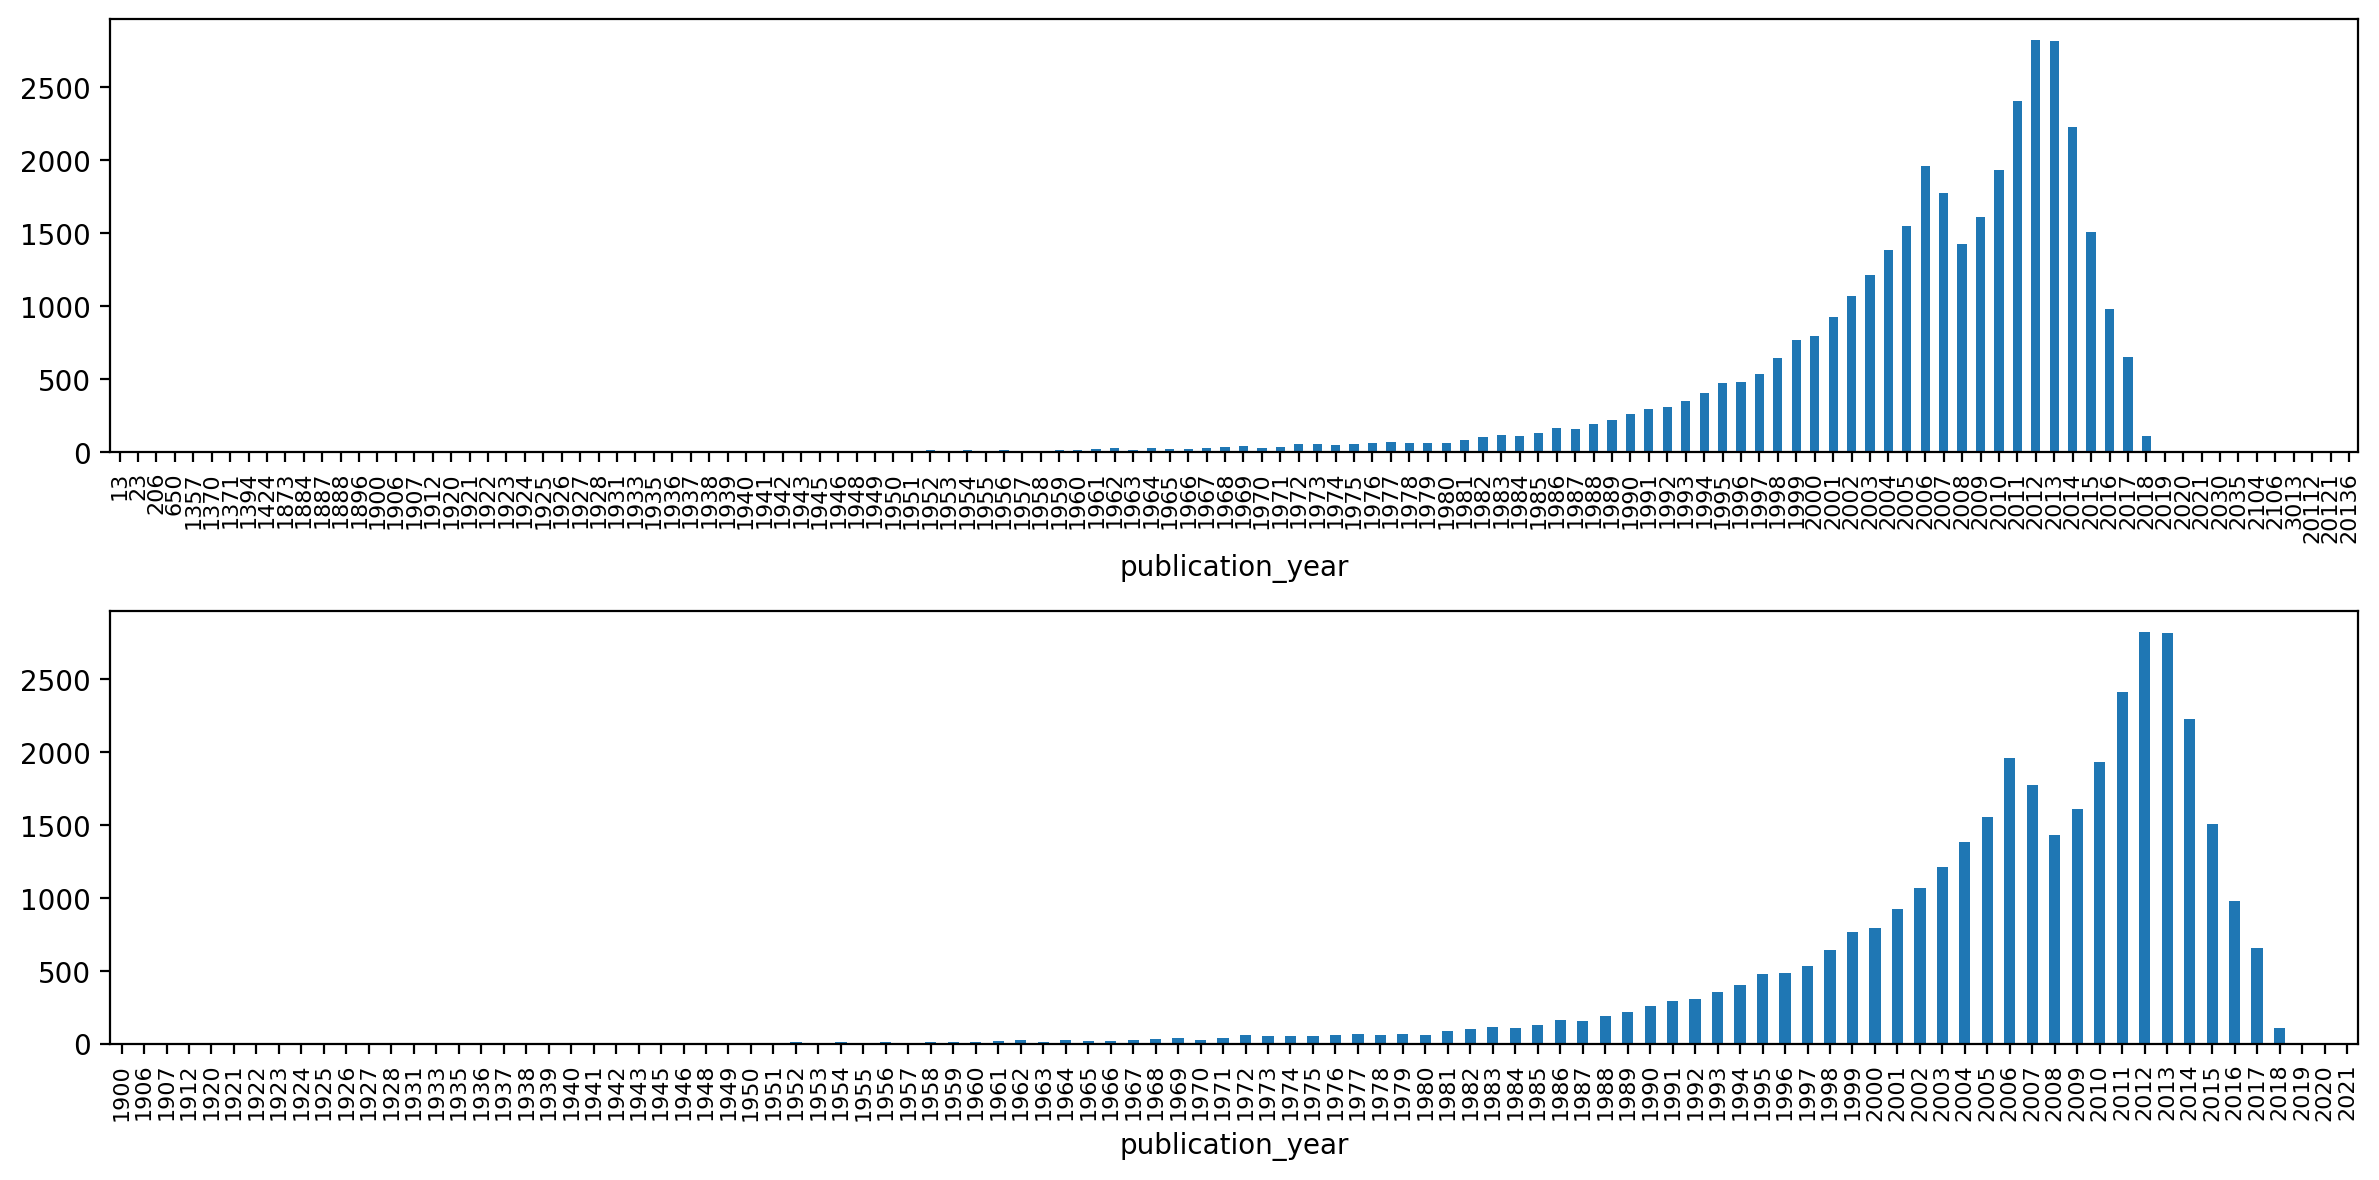

In [ ]:
# распределение книг по годам публикации

fig, axs = plt.subplots(2, 1, figsize=(12, 6))

ax = axs[0]
books["publication_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=8)

ax = axs[1]
books.query("publication_year >= 1900 and publication_year <= 2025")["publication_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=8)

fig.tight_layout()

# События по месяцам

In [ ]:
from pandas.tseries.offsets import MonthEnd

interactions["started_at_month"] = pd.to_datetime(interactions["started_at"]).dt.to_period('M').dt.to_timestamp().dt.date

In [ ]:
interactions_by_month = interactions.groupby("started_at_month").agg(events=("started_at", "count"), users=("user_id", "nunique")).reset_index()

In [ ]:
interactions_by_month

,started_at_month,events,users
0,2007-01-01,1993,1071
1,2007-02-01,201,135
2,2007-03-01,222,152
3,2007-04-01,201,135
4,2007-05-01,204,138
...,...,...,...
127,2017-08-01,202129,93040
128,2017-09-01,172187,82694
129,2017-10-01,108107,58076
130,2017-11-01,565,475


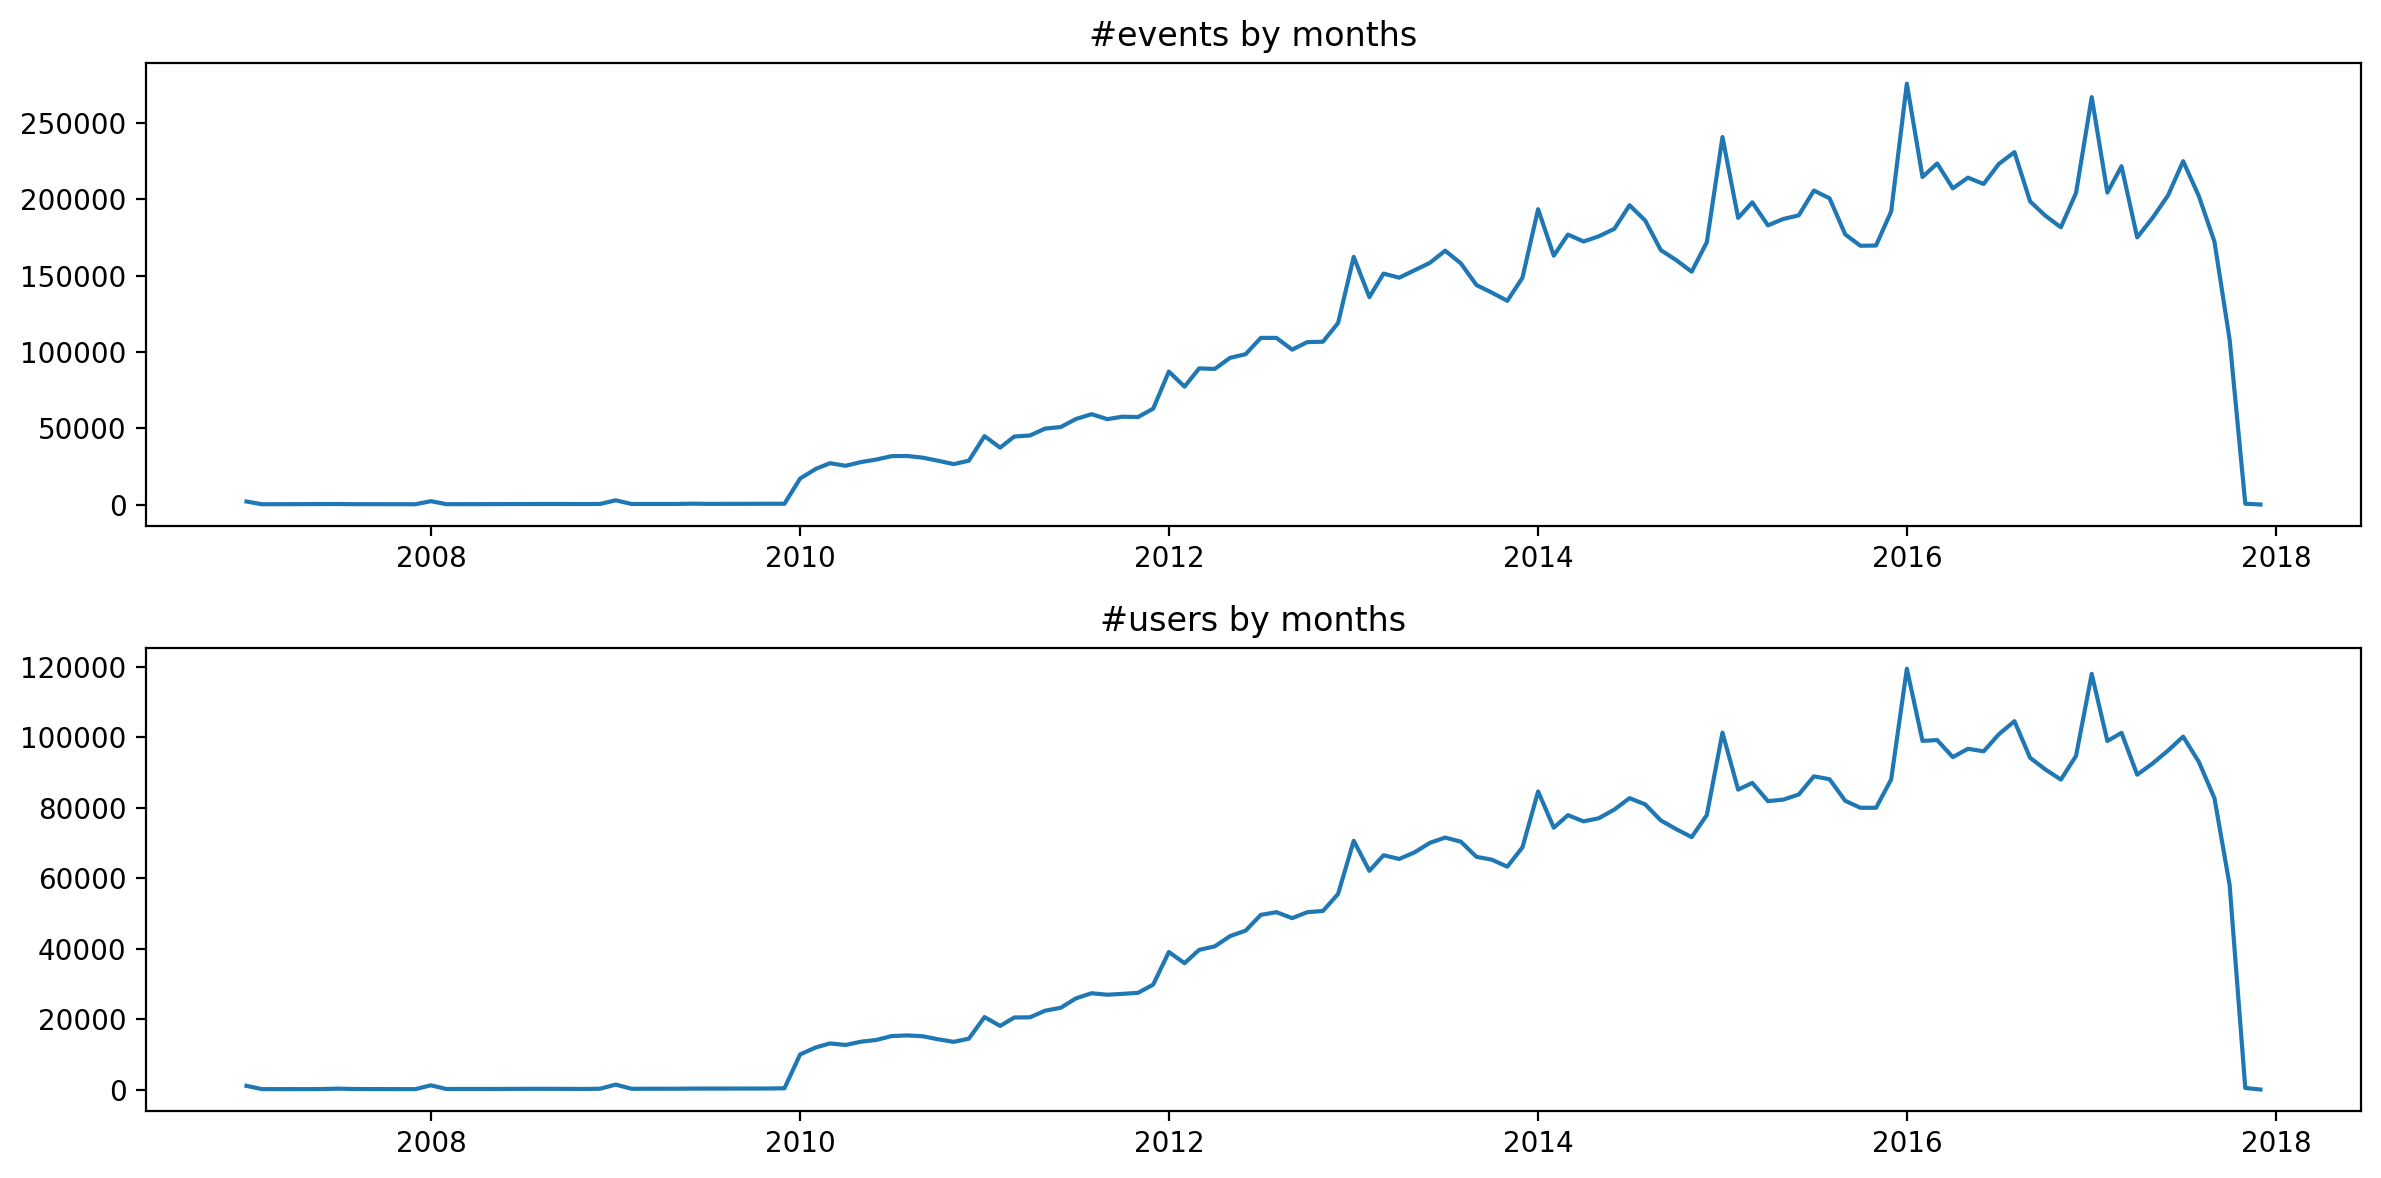

In [ ]:
# распределение взаимодействий по годам

fig, axs = plt.subplots(2, 1, figsize=(12, 6))

ax = axs[0]
ax.plot(interactions_by_month["started_at_month"], interactions_by_month["events"])
# ax.tick_params(axis='x', labelsize=8)
ax.set_title("#events by months")

ax = axs[1]
ax.plot(interactions_by_month["started_at_month"], interactions_by_month["users"])
# ax.tick_params(axis='x', labelsize=8)
ax.set_title("#users by months")

fig.tight_layout()

# Преобработка

Примем новые именования:
- books -> items (более обобщённое название)
- interactions -> events (несколько короче, удобнее в коде)

In [6]:
items = books.copy()
events = interactions.copy()

In [ ]:
#del books
#del interactions

In [7]:
# оставим события только до ноября 2017

event_cutoff_date = pd.to_datetime("2017-11-01").date()
events = events.query("started_at < @event_cutoff_date and read_at < @event_cutoff_date").copy()

# Ваш код здесь

In [8]:
# удалите события, для которых нет рейтинга;
print('delete rating == 0, percents: ', events.query('rating == 0').shape[0]/events.shape[0])
events = events.query('rating > 0')


delete rating == 0, percents:  0.08157044608184211


In [9]:
# оставьте события только c признаком is_read=True;
print('delete is_read != True, percents: ', events.query('is_read == False').shape[0]/events.shape[0])
events = events.query('is_read == True')

delete is_read != True, percents:  0.0


In [ ]:
# оставьте только тех пользователей, у которых две прочитанные книги и более.

users_count = events.groupby('user_id').agg(count=('user_id', 'count'))

print('delete users read less than 2 books, percents: ', users_count.query('count < 2').value_counts())
users_less2book = users_count.query('count < 2').reset_index()['user_id'].values

events = events.query('user_id not in @users_less2book')
events


delete users read less than 2 books, percents:  count
1        85196
Name: count, dtype: int64


,user_id,book_id,started_at,read_at,is_read,rating,is_reviewed
0,8842281e1d1347389f2ab93d60773d4d,22034,2015-07-12,2015-07-17,True,5,False
1,8842281e1d1347389f2ab93d60773d4d,22318578,2015-06-07,2015-08-09,True,5,True
2,8842281e1d1347389f2ab93d60773d4d,22551730,2015-06-24,2015-07-11,True,4,True
3,8842281e1d1347389f2ab93d60773d4d,22816087,2015-09-27,2015-11-04,True,5,True
5,8842281e1d1347389f2ab93d60773d4d,17910054,2015-03-04,2015-07-28,True,3,False
...,...,...,...,...,...,...,...
12914452,d890e8079d8896e0cc6c4f178634850a,5297,2017-02-07,2017-02-26,True,5,False
12914453,d890e8079d8896e0cc6c4f178634850a,4900,2016-12-22,2016-12-29,True,2,False
12914454,d890e8079d8896e0cc6c4f178634850a,14836,2016-11-29,2017-01-15,True,3,False
12914456,b0883ebf8e31731f1c5d91e678c26666,10210,2012-06-05,2013-01-17,True,5,False


In [11]:
interactions_before = 12890434
print('Итого удалено событий', interactions_before - events.shape[0], round((interactions_before - events.shape[0])/interactions_before, 2), '%')

Итого удалено событий 1139348 0.09 %


In [12]:
# перименуйте идентификатор book_id — в item_id, причём как в items, так и в events.
items.rename(columns={'book_id': 'item_id'}, inplace=True)
events.rename(columns={'book_id': 'item_id'}, inplace=True)

In [13]:
# А ещё для удобства перекодируйте идентификаторы пользователей из символьного вида (92f960b6da4be49c7955794c6331d759) в числовой
#   - Все оставшиеся после обработки данных идентификаторы нужно отсортировать по возрастанию и последовательно пронумеровать, начиная с 1 000 000. 
#   - Эти значения и будут новыми идентификаторами пользователей.

user_ids = pd.DataFrame(events['user_id'].sort_values().unique(), columns=['old_id'])
user_ids['new_user_id'] = 1000000 + user_ids.index
user_ids.set_index('old_id', inplace=True)

events['old_user_id'] = events['user_id']
events = events.merge(user_ids, left_on='user_id', right_on='old_id')
events['user_id'] = events['new_user_id']
events.drop(columns='new_user_id')
events


,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
0,1229132,22034,2015-07-12,2015-07-17,True,5,False,8842281e1d1347389f2ab93d60773d4d,1229132
1,1229132,22318578,2015-06-07,2015-08-09,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132
2,1229132,22551730,2015-06-24,2015-07-11,True,4,True,8842281e1d1347389f2ab93d60773d4d,1229132
3,1229132,22816087,2015-09-27,2015-11-04,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132
4,1229132,17910054,2015-03-04,2015-07-28,True,3,False,8842281e1d1347389f2ab93d60773d4d,1229132
...,...,...,...,...,...,...,...,...,...
11751081,1364473,5297,2017-02-07,2017-02-26,True,5,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751082,1364473,4900,2016-12-22,2016-12-29,True,2,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751083,1364473,14836,2016-11-29,2017-01-15,True,3,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751084,1297020,10210,2012-06-05,2013-01-17,True,5,False,b0883ebf8e31731f1c5d91e678c26666,1297020


In [14]:
# 8f50136afeb65c55cec7b3d306c24b03
events[events['old_user_id']=='8f50136afeb65c55cec7b3d306c24b03']

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
9944036,1241243,253058,2012-12-29,2013-01-22,True,3,True,8f50136afeb65c55cec7b3d306c24b03,1241243
9944037,1241243,10572,2012-01-02,2013-01-27,True,5,False,8f50136afeb65c55cec7b3d306c24b03,1241243


# Сохранение результатов

In [15]:
data_path = 'data/preprocess/'
items.to_parquet(data_path + "items.par")

In [16]:
events.to_parquet(data_path + "events.par")